<a href="https://colab.research.google.com/github/cheruu23/webscraper-using-colab/blob/main/ethiopisndigitalappeda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install google-play-scraper
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google_play_scraper import app, reviews_all, Sort
from textblob import TextBlob
from wordcloud import WordCloud, STOPWORDS
import re

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00


In [ ]:
app_ids = {
    "Telebirr": "cn.tydic.ethiopay",
    "EBirr": "com.safarifone.ebirr",
    "CBEBirr": "prod.cbe.birr",
    "CBE Mobile Banking": "com.combanketh.mobilebanking",
    "BoA Mobile Banking": "com.boa.boaMobileBanking",
    "Apollo (BoA)": "com.boa.apollo",
    "Awash Bank": "com.sc.awashpay",
    "Nib Bank": "com.nib.NibMobileBanking",
    "Dashen Bank": "com.dashen.dashensuperapp",
    "Oromia Bank": "com.oromiabank.mobilebanking",
    "Coop Mobile Banking": "com.coopbankoromiasc.OLB"
}

In [ ]:
import time

all_reviews = []

for name, app_id in app_ids.items():
    print(f"Scraping {name} ({app_id})...")
    try:
        # Scrape all reviews (language='en' gets English; you can add 'am' if needed)
        revs = reviews_all(
            app_id,
            sleep_milliseconds=100,  # polite delay
            lang='en',
            country='et'             # Ethiopia store
        )
        for r in revs:
            r['app_name'] = name
            r['app_id'] = app_id
        all_reviews.extend(revs)
        print(f"  -> {len(revs)} reviews")
    except Exception as e:
        print(f"  Error: {e}")
    time.sleep(5)  # wait between apps

df = pd.DataFrame(all_reviews)
df.to_csv("ethiopia_banking_apps_reviews.csv", index=False)

Scraping Telebirr (cn.tydic.ethiopay)...
  -> 16580 reviews
Scraping EBirr (com.safarifone.ebirr)...
  -> 1637 reviews
Scraping CBEBirr (prod.cbe.birr)...
  -> 2305 reviews
Scraping CBE Mobile Banking (com.combanketh.mobilebanking)...
  -> 9812 reviews
Scraping BoA Mobile Banking (com.boa.boaMobileBanking)...
  -> 1450 reviews
Scraping Apollo (BoA) (com.boa.apollo)...
  -> 2079 reviews
Scraping Awash Bank (com.sc.awashpay)...
  -> 3409 reviews
Scraping Nib Bank (com.nib.NibMobileBanking)...
  -> 235 reviews
Scraping Dashen Bank (com.dashen.dashensuperapp)...
  -> 1050 reviews
Scraping Oromia Bank (com.oromiabank.mobilebanking)...
  -> 165 reviews
Scraping Coop Mobile Banking (com.coopbankoromiasc.OLB)...
  -> 240 reviews


In [ ]:
meta_list = []
for name, app_id in app_ids.items():
    try:
        info = app(app_id, lang='en', country='et')
        info['app_name'] = name
        meta_list.append(info)
    except Exception as e:
        print(f"Meta error {name}: {e}")
    time.sleep(2)

meta_df = pd.DataFrame(meta_list)
meta_df.to_csv("app_metadata.csv", index=False)

In [ ]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38962 entries, 0 to 38961
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              38962 non-null  object        
 1   userName              38962 non-null  object        
 2   userImage             38962 non-null  object        
 3   content               38955 non-null  object        
 4   score                 38962 non-null  int64         
 5   thumbsUpCount         38962 non-null  int64         
 6   reviewCreatedVersion  29227 non-null  object        
 7   at                    38962 non-null  datetime64[ns]
 8   replyContent          129 non-null    object        
 9   repliedAt             129 non-null    datetime64[ns]
 10  appVersion            29227 non-null  object        
 11  app_name              38962 non-null  object        
 12  app_id                38962 non-null  object        
dtypes: datetime64[ns

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,app_id
0,f866462c-9ce7-452e-a4f0-fe4c115e4c4c,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"from yadi, just for learning due to eda- at AAU",5,0,None,2026-06-09 15:00:54,None,NaT,None,Telebirr,cn.tydic.ethiopay
1,2010279c-0187-4ae8-b4ac-90220f092087,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,1.2.7.002,2026-06-09 14:31:05,None,NaT,1.2.7.002,Telebirr,cn.tydic.ethiopay
2,9d3f87d6-f2fb-4782-9f91-83dfc0eeef26,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,better app continue!,4,0,1.2.7.002,2026-06-09 06:03:50,None,NaT,1.2.7.002,Telebirr,cn.tydic.ethiopay
3,222ed5c6-2f02-4833-bb90-b022edbd04fe,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Solutionsproblem,5,0,None,2026-06-08 21:35:57,None,NaT,None,Telebirr,cn.tydic.ethiopay
4,4eaa0daf-5c8a-42a1-9bb9-373a9779777a,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,good,3,0,1.2.9.004,2026-06-08 18:40:24,None,NaT,1.2.9.004,Telebirr,cn.tydic.ethiopay


## Most Common Words in 1-Star Reviews

In [ ]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re

nltk.download('stopwords')

# Filter for 1-star reviews
one_star_reviews = df[df['score'] == 1]

# Combine all 1-star review content into a single string
all_one_star_text = ' '.join(one_star_reviews['content'].dropna().astype(str))

# Clean the text
# Remove non-alphabetic characters and convert to lowercase
cleaned_text = re.sub('[^a-zA-Z]', ' ', all_one_star_text).lower()

# Tokenize and remove stopwords
words = cleaned_text.split()
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in words if word not in stop_words and len(word) > 2] # Remove short words too

# Count word frequencies
word_counts = Counter(filtered_words)

# Display the 20 most common words
print("Top 20 most common words in 1-star reviews:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Top 20 most common words in 1-star reviews:
app: 2846
update: 675
working: 646
work: 640
even: 495
use: 474
good: 473
please: 457
bank: 412
worst: 379
time: 352
fix: 311
ever: 308
account: 301
bad: 300
money: 300
open: 270
application: 262
mobile: 258
phone: 250


## Word Cloud for 1-Star Reviews

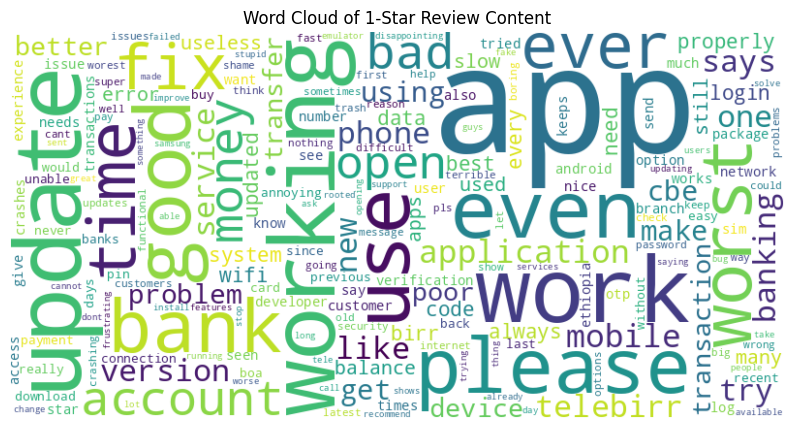

In [ ]:
# Generate a word cloud from the word frequencies
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

# Display the word cloud
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of 1-Star Review Content')
plt.show()

## Exploratory Data Analysis for Each App


--- EDA for Telebirr ---
Number of reviews for Telebirr: 16580
Score distribution:
score
1    13.787696
2     2.907117
3     4.457177
4     8.305187
5    70.542823
Name: proportion, dtype: float64


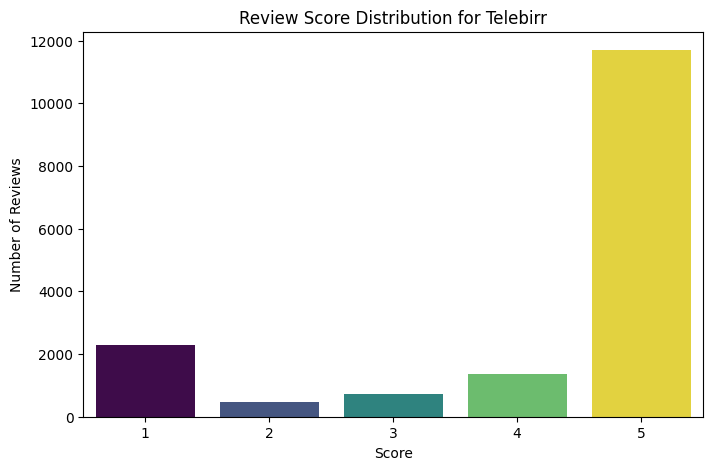


--- EDA for EBirr ---
Number of reviews for EBirr: 1637
Score distribution:
score
1    11.973122
2     2.871106
3     4.398290
4     7.025046
5    73.732437
Name: proportion, dtype: float64


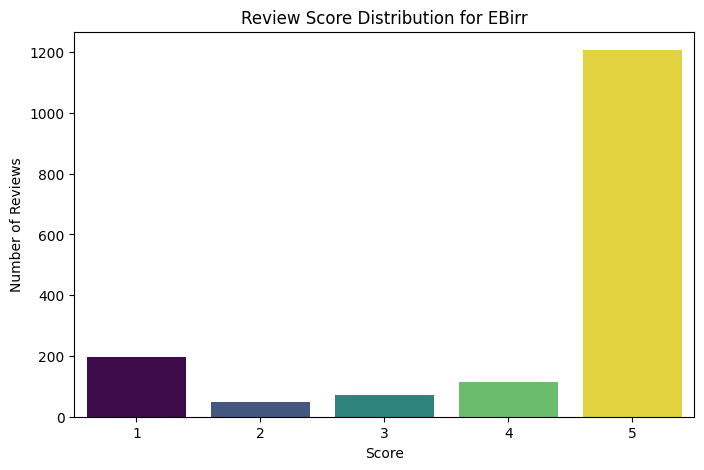


--- EDA for CBEBirr ---
Number of reviews for CBEBirr: 2305
Score distribution:
score
1    15.010846
2     3.427332
3     5.509761
4     8.546638
5    67.505423
Name: proportion, dtype: float64


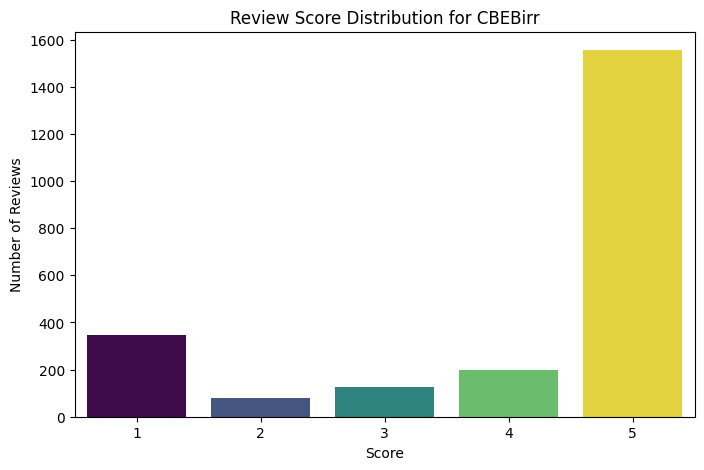


--- EDA for CBE Mobile Banking ---
Number of reviews for CBE Mobile Banking: 9812
Score distribution:
score
1    16.021199
2     4.107216
3     5.962087
4     9.467998
5    64.441500
Name: proportion, dtype: float64


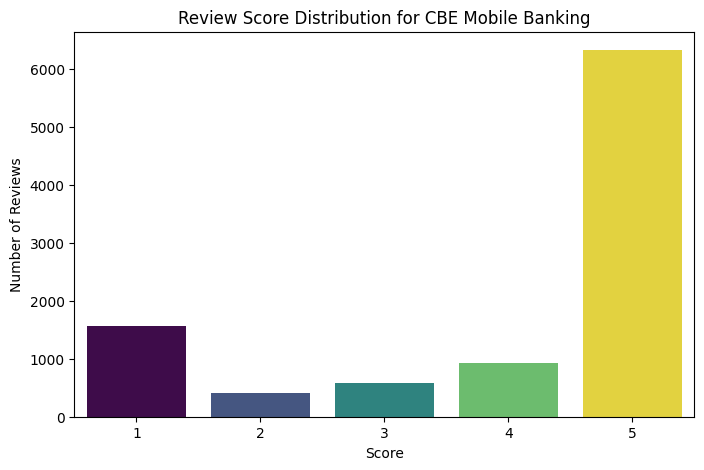


--- EDA for BoA Mobile Banking ---
Number of reviews for BoA Mobile Banking: 1450
Score distribution:
score
1    37.103448
2     4.344828
3     5.517241
4     5.448276
5    47.586207
Name: proportion, dtype: float64


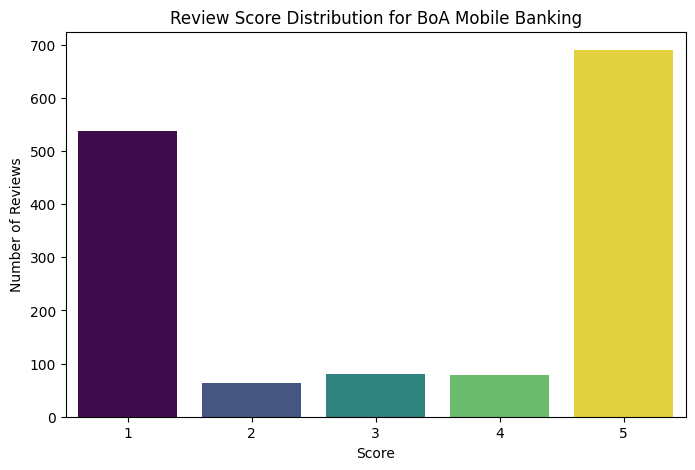


--- EDA for Apollo (BoA) ---
Number of reviews for Apollo (BoA): 2079
Score distribution:
score
1    30.303030
2     5.916306
3     4.906205
4     6.060606
5    52.813853
Name: proportion, dtype: float64


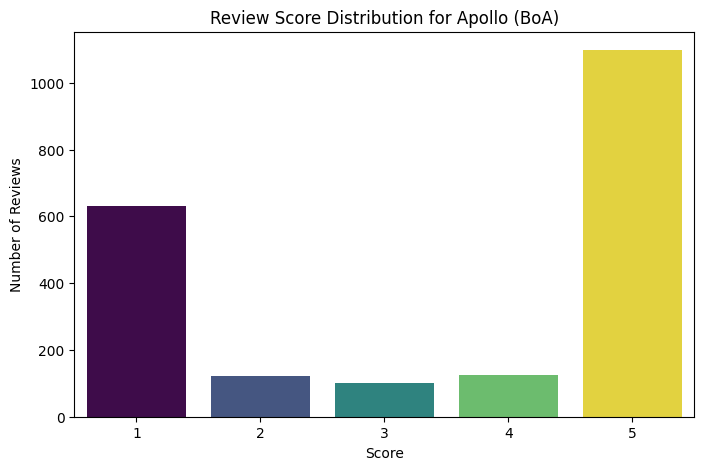


--- EDA for Awash Bank ---
Number of reviews for Awash Bank: 3409
Score distribution:
score
1     9.973599
2     3.314755
3     4.253447
4    10.032268
5    72.425931
Name: proportion, dtype: float64


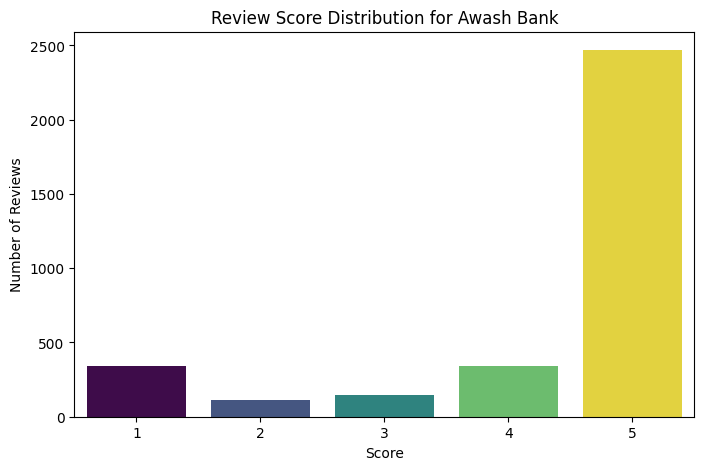


--- EDA for Nib Bank ---
Number of reviews for Nib Bank: 235
Score distribution:
score
1    17.446809
2     4.255319
3     4.255319
4     5.531915
5    68.510638
Name: proportion, dtype: float64


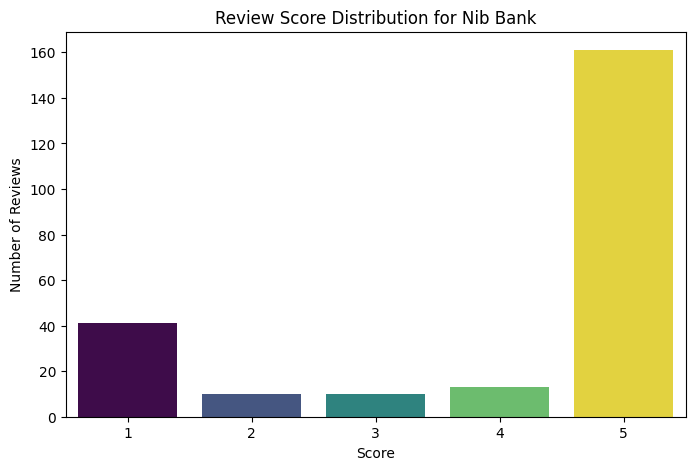


--- EDA for Dashen Bank ---
Number of reviews for Dashen Bank: 1050
Score distribution:
score
1    15.238095
2     4.190476
3     3.904762
4     5.809524
5    70.857143
Name: proportion, dtype: float64


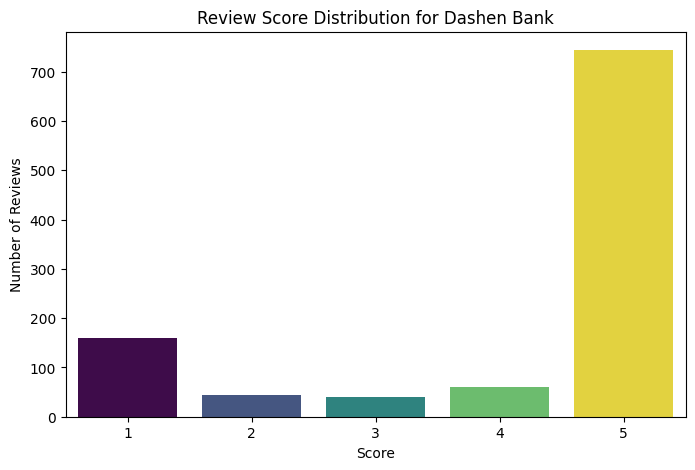


--- EDA for Oromia Bank ---
Number of reviews for Oromia Bank: 165
Score distribution:
score
1    16.363636
2     1.818182
3     6.060606
4     7.878788
5    67.878788
Name: proportion, dtype: float64


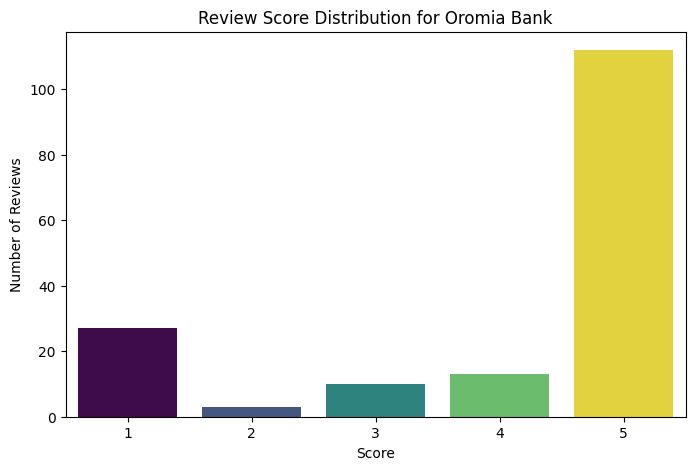


--- EDA for Coop Mobile Banking ---
Number of reviews for Coop Mobile Banking: 240
Score distribution:
score
1    27.083333
2     4.583333
3     3.750000
4     6.250000
5    58.333333
Name: proportion, dtype: float64


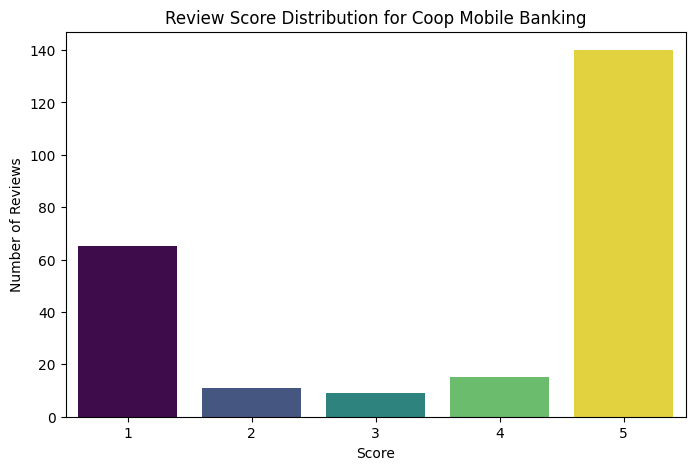

In [ ]:
for app_name in df['app_name'].unique():
    print(f"\n--- EDA for {app_name} ---")
    app_df = df[df['app_name'] == app_name]

    print(f"Number of reviews for {app_name}: {len(app_df)}")
    print("Score distribution:")
    print(app_df['score'].value_counts(normalize=True).sort_index() * 100)

    # Plotting score distribution for each app
    plt.figure(figsize=(8, 5))
    sns.countplot(x='score', data=app_df, hue='score', palette='viridis', legend=False)
    plt.title(f'Review Score Distribution for {app_name}')
    plt.xlabel('Score')
    plt.ylabel('Number of Reviews')
    plt.show()

## Average Review Score for Each App

In [ ]:
average_scores = df.groupby('app_name')['score'].mean().sort_values(ascending=False)
display(average_scores.reset_index())

,app_name,score
0,Awash Bank,4.316222
1,EBirr,4.276726
2,Telebirr,4.189083
3,Dashen Bank,4.128571
4,CBEBirr,4.101085
5,Oromia Bank,4.090909
6,Nib Bank,4.034043
7,CBE Mobile Banking,4.021110
8,Coop Mobile Banking,3.641667
9,Apollo (BoA),3.451659


## Sentiment Score Distribution for the App with the Lowest Rating

The app with the lowest average rating is: BoA Mobile Banking


,sentiment_category,proportion
0,Positive,48.275862
1,Neutral,33.448276
2,Negative,18.275862


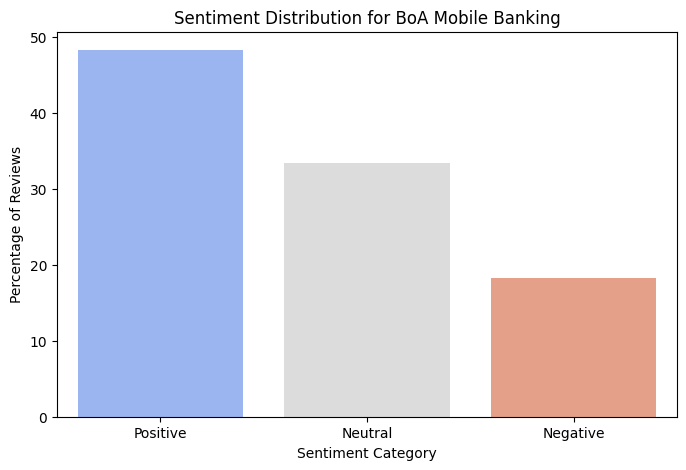

In [ ]:
# Identify the app with the lowest average rating
lowest_rated_app_name = average_scores.idxmin()
print(f"The app with the lowest average rating is: {lowest_rated_app_name}")

# Filter reviews for this app
lowest_app_reviews = df[df['app_name'] == lowest_rated_app_name].copy()

# Calculate sentiment for each review
lowest_app_reviews['sentiment'] = lowest_app_reviews['content'].astype(str).apply(lambda text: TextBlob(text).sentiment.polarity)

# Categorize sentiment
def categorize_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:


        return 'Neutral'

lowest_app_reviews['sentiment_category'] = lowest_app_reviews['sentiment'].apply(categorize_sentiment)

# Display sentiment distribution
sentiment_distribution = lowest_app_reviews['sentiment_category'].value_counts(normalize=True) * 100
display(sentiment_distribution.reset_index())

# Plotting sentiment distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, hue=sentiment_distribution.index, palette='coolwarm', legend=False)
plt.title(f'Sentiment Distribution for {lowest_rated_app_name}')
plt.xlabel('Sentiment Category')
plt.ylabel('Percentage of Reviews')
plt.show()

In [ ]:
isnull().sum()

NameError: name 'isnull' is not defined